In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.67532051/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {'HI':'15.40, -0.06, +0.06',
            'CII':'<13.46',
            'CIII':'13.97, -0.03, +0.03',
            'CIV':'13.73, -0.05, +0.05',
            'NII':'<13.23',
            'NIII':'<13.42',
            'NV':'<13.72',
            'OII':'<13.29',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.95, -0.03, +0.03',
            'NeVIII':'<13.35',
            'MgII':'<11.52',
            'AlIII':'<12.29',
            'SiII':'<13.27',
            'SiIII':'<12.77',
            'SVI':'<12.79',
            'FeII':'<11.90'}

Plot column densities

In [15]:
logN_HI_test = 15.40
log_hdens_test = -3.3
O_H_test = -0.6
log_metals_test = get_metal_abundance(O_H_test)

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp)

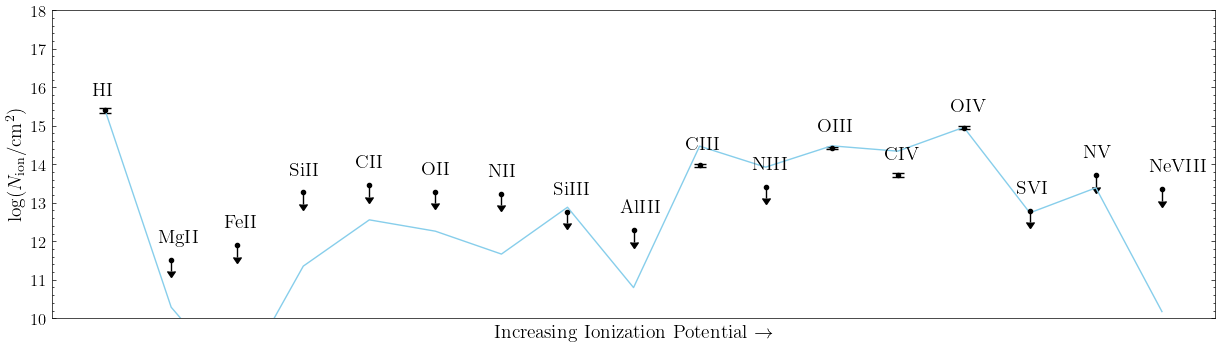

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Define overridden prior and likelihood functions

In [18]:
# Assume solar abundance patterns throughout
# Also don't vary HI column density

def lambda_log_prior(params):
    
    # Only parameters being varied
    logN_HI, log_hdens, O_H = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {}])
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [19]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    logN_HI, log_hdens, O_H = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [20]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

$\alpha$-element only, solar abundance pattern fit

In [21]:
#ions_alpha = ['HI', 'MgII', 'SiII', 'OII', 'SiIII', 'OIII', 'OIV', 'SVI', 'NeVIII']
ions_alpha = ['HI', 'OIII', 'OIV']

In [22]:
logN_dict_alpha = {ion: logN_dict[ion] for ion in ions_alpha}

In [23]:
pos = np.array([logN_HI_test, log_hdens_test, O_H_test]) + 1e-4 * np.random.randn(500, 3)
nwalkers, ndim = pos.shape

In [24]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_alpha, species_logN_interp)
)

In [25]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [02:49<00:00,  2.95it/s]


In [26]:
flat_samples_alpha = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['logN_HI', 'log_hdens', '[O/H]'])
#flat_samples_alpha.to_csv(savedir+'alpha_solar_flat.csv', index=False)

#flat_samples_alpha = pd.read_csv(savedir+'alpha_solar_flat.csv')

In [27]:
flat_samples_alpha['[M/H]'] = [get_metal_abundance(O_H) for O_H in flat_samples_alpha['[O/H]']]

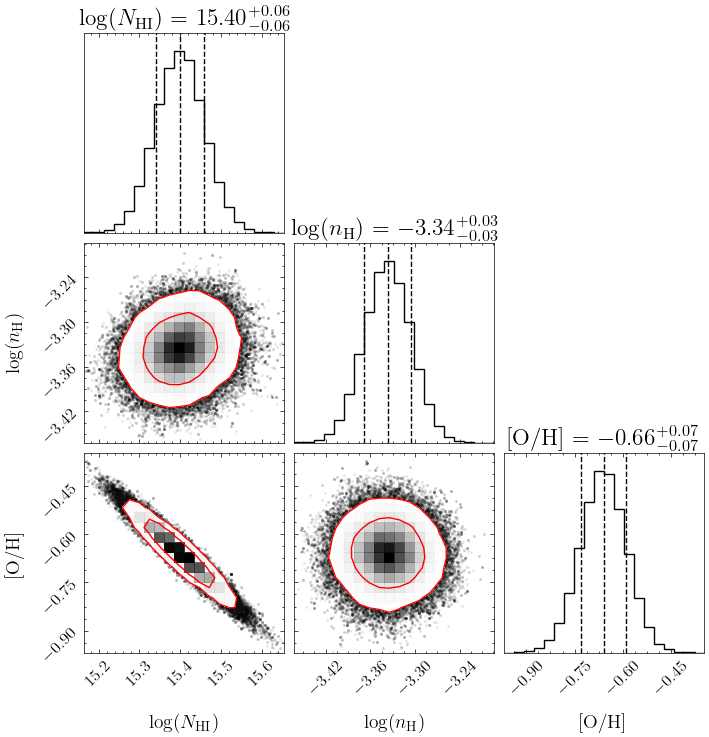

In [28]:
fig = corner.corner(
    flat_samples_alpha.loc[:, ['logN_HI', 'log_hdens', '[O/H]']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_{\mathrm{HI}})$', r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Plot the samples over the measured column densities

In [66]:
sample_indices_alpha = np.random.randint(low=0, high=len(flat_samples_alpha), size=100)

In [67]:
ions_ordered = [s for s in list(IP_dict.keys()) if s in list(logN_dict.keys())]

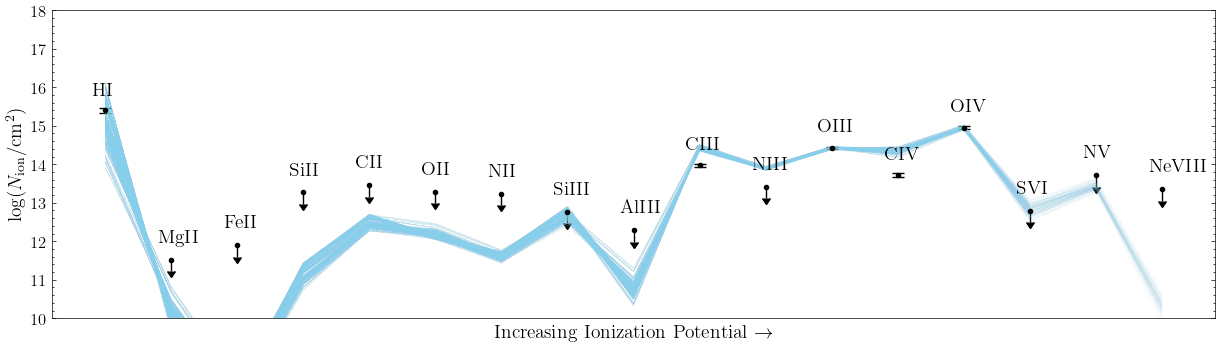

In [69]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_alpha)):
    
    idx = sample_indices_alpha[i]
    flat_samples_row = flat_samples_alpha.iloc[i]
    logN_HI = flat_samples_row['logN_HI']
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['[M/H]']
    
    logN_species_test = []

    for i in range(len(ions_ordered)):

        ion = ions_ordered[i] 
        s = ion_species_dict[ion]

        # Get interpolated column density from CLOUDY grid
        logN_species_test.append(species_logN_interp[s]([logN_HI, log_hdens, log_metals])[0])
        
        # Plot
        ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue', lw=.2, alpha=.1)